In [13]:
# ==========================================
# Cell 1: Install / import dependencies
# ==========================================

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DEFAULT_SEED, make_params
from initialization import initialize_model
from main import run_one_round
from utils import set_random_seed
from visualization import (
    plot_final_opinion_distribution,
    plot_network_and_homophily,
    plot_opinion_leaders,
    plot_time_series_summaries,
    prepare_graph_for_visualization,
)


In [14]:
# ==========================================
# Cell 2: Random seed and helper functions
# ==========================================

SEED = DEFAULT_SEED
rng = set_random_seed(SEED)
SEED


42

In [15]:
# ==========================================
# Cell 3: Define model parameters
# ==========================================

params = make_params()
params


{'N': 400,
 'm_BA': 3,
 'leader_in_degree_threshold': 15,
 'T_rounds': 10,
 'opinion_mean': 0.0,
 'opinion_std': 0.35,
 'Abar_low': 0.2,
 'Abar_high': 0.8,
 'rho_A': 0.6,
 'omega1': 0.1,
 'omega2': 0.2,
 'omega3': 0.05,
 'N_E': 10.0,
 'kappa': 2.0,
 'alpha0': -2.0,
 'alpha1': 1.8,
 'alpha2': 1.2,
 'alpha3': 0.25,
 'alpha_B': 1.5,
 'beta1': 0.6,
 'beta2': 0.4,
 'beta3': 0.5,
 'beta4': 0.7,
 'c0': 0.55,
 'epsilon_std': 0.15,
 'epsilon_ambiguity': 0.4,
 'gamma0': 0.15,
 'gamma1': 0.55,
 'gamma2': 0.35,
 'gamma3': 0.45,
 'gamma4': 0.25,
 'c_C': 0.1,
 'eta_C_std': 0.12,
 'delta0': 0.05,
 'delta1': 0.55,
 'delta2': 0.45,
 'delta3': 0.4,
 'delta4': 0.3,
 'c_T': 0.18,
 'eta_T_std': 0.12,
 'p_O': 0.02,
 'beta0_diff': -3.2,
 'beta1_diff': 0.8,
 'beta2_diff': 0.7,
 'w_o': 1.0,
 'w_l': 1.5,
 'gamma_R': 0.05,
 'gamma_A': 0.04,
 'gamma_B': 0.06,
 'gamma_R_L': 0.03,
 'gamma_A_L': 0.02,
 'gamma_B_L': 0.03,
 'a1': 1.0,
 'a2': 0.6,
 'a3': 0.7,
 'a4': 1.2,
 'b_T': 0.5,
 'b_O': 0.4,
 'b_TO': 0.8,
 'lambda

In [16]:
# ==========================================
# Cell 4: Initialize BA network and agent states
# ==========================================

G, G_initial_undirected, agents, blocks, pos = initialize_model(params, seed=SEED)

print('Initialization finished.')
print(f"Nodes: {G.number_of_nodes()}")
print(f"Directed edges: {G.number_of_edges()}")
print(f"Opinion leaders: {agents['L'].sum()}")
agents.head()


Initialization finished.
Nodes: 400
Directed edges: 1191
Opinion leaders: 7


,node,F_t,L,o_t,s_t,Abar,A_t,m_t,O_t,C_t,M_pC_prev,M_pT_prev,M_nC_prev,M_nT_prev
0,0,19,1,0.038715,1,0.608798,0.608798,0.077275,0,0,0.0,0.0,0.0,0.0
1,1,8,0,0.000469,1,0.315153,0.315153,0.000938,0,0,0.0,0.0,0.0,0.0
2,2,3,0,0.515534,1,0.305277,0.305277,0.774336,0,0,0.0,0.0,0.0,0.0
3,3,14,0,-0.857805,-1,0.687193,0.687193,-0.937332,0,0,0.0,0.0,0.0,0.0
4,4,25,1,-0.496189,-1,0.358827,0.358827,-0.758375,0,0,0.0,0.0,0.0,0.0


In [17]:
# ==========================================
# Cell 5: Define one-round simulation function
# ==========================================

# The one-round workflow now lives in the local project code
# so that the notebook and scripts share the same implementation.
run_one_round


<function main.run_one_round(graph, agents, blocks: 'dict', params: 'dict', rng)>

In [18]:
# ==========================================
# Cell 6: Run the simulation for multiple rounds
# ==========================================

round_records = []
all_posts_by_round = {}
all_exposure_sets_by_round = {}

for t in range(1, params['T_rounds'] + 1):
    G, agents, posts, exposure_sets, summary = run_one_round(G, agents, blocks, params, rng)
    summary['round'] = t
    round_records.append(summary)
    all_posts_by_round[t] = posts
    all_exposure_sets_by_round[t] = exposure_sets
    print(
        f"Round {t:02d} | "
        f"Creators={summary['actual_creators']:3d} | "
        f"Support={summary['support_posts']:3d} | "
        f"Oppose={summary['oppose_posts']:3d} | "
        f"Toxic={summary['toxic_posts']:3d} | "
        f"AvgExposure={summary['avg_exposure_size']:.2f} | "
        f"Edges={summary['edge_count']}"
    )

import pandas as pd
history_df = pd.DataFrame(round_records)
history_df


Round 01 | Creators= 72 | Support= 31 | Oppose= 41 | Toxic= 58 | AvgExposure=2.78 | Edges=1243
Round 02 | Creators=109 | Support= 15 | Oppose= 94 | Toxic= 92 | AvgExposure=5.04 | Edges=1348
Round 03 | Creators=140 | Support=  1 | Oppose=139 | Toxic=139 | AvgExposure=7.58 | Edges=1359
Round 04 | Creators=177 | Support=  0 | Oppose=177 | Toxic=177 | AvgExposure=8.76 | Edges=1482
Round 05 | Creators=165 | Support=  0 | Oppose=165 | Toxic=165 | AvgExposure=8.69 | Edges=1535
Round 06 | Creators=175 | Support=  0 | Oppose=175 | Toxic=175 | AvgExposure=9.88 | Edges=1551
Round 07 | Creators=178 | Support=  0 | Oppose=178 | Toxic=178 | AvgExposure=8.48 | Edges=1575
Round 08 | Creators=188 | Support=  0 | Oppose=188 | Toxic=188 | AvgExposure=9.57 | Edges=1590
Round 09 | Creators=183 | Support=  0 | Oppose=183 | Toxic=183 | AvgExposure=9.34 | Edges=1620
Round 10 | Creators=214 | Support=  0 | Oppose=214 | Toxic=214 | AvgExposure=9.46 | Edges=1646


,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,edge_count,round
0,125,72,14,58,31,41,2.7825,-0.052838,0.493340,1243,1
1,138,109,17,92,15,94,5.0375,-0.060555,0.747284,1348,2
2,152,140,1,139,1,139,7.5850,-0.050348,0.972455,1359,3
3,177,177,0,177,0,177,8.7575,-0.049793,0.999812,1482,4
4,165,165,0,165,0,165,8.6925,-0.050000,1.000000,1535,5
5,175,175,0,175,0,175,9.8825,-0.050000,1.000000,1551,6
6,178,178,0,178,0,178,8.4850,-0.050000,1.000000,1575,7
7,189,188,0,188,0,188,9.5675,-0.050000,1.000000,1590,8
8,183,183,0,183,0,183,9.3400,-0.050000,1.000000,1620,9
9,214,214,0,214,0,214,9.4625,-0.050000,1.000000,1646,10


In [19]:
# ==========================================
# Cell 7: Show round-by-round summary
# ==========================================

display(history_df)


,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,edge_count,round
0,125,72,14,58,31,41,2.7825,-0.052838,0.493340,1243,1
1,138,109,17,92,15,94,5.0375,-0.060555,0.747284,1348,2
2,152,140,1,139,1,139,7.5850,-0.050348,0.972455,1359,3
3,177,177,0,177,0,177,8.7575,-0.049793,0.999812,1482,4
4,165,165,0,165,0,165,8.6925,-0.050000,1.000000,1535,5
5,175,175,0,175,0,175,9.8825,-0.050000,1.000000,1551,6
6,178,178,0,178,0,178,8.4850,-0.050000,1.000000,1575,7
7,189,188,0,188,0,188,9.5675,-0.050000,1.000000,1590,8
8,183,183,0,183,0,183,9.3400,-0.050000,1.000000,1620,9
9,214,214,0,214,0,214,9.4625,-0.050000,1.000000,1646,10


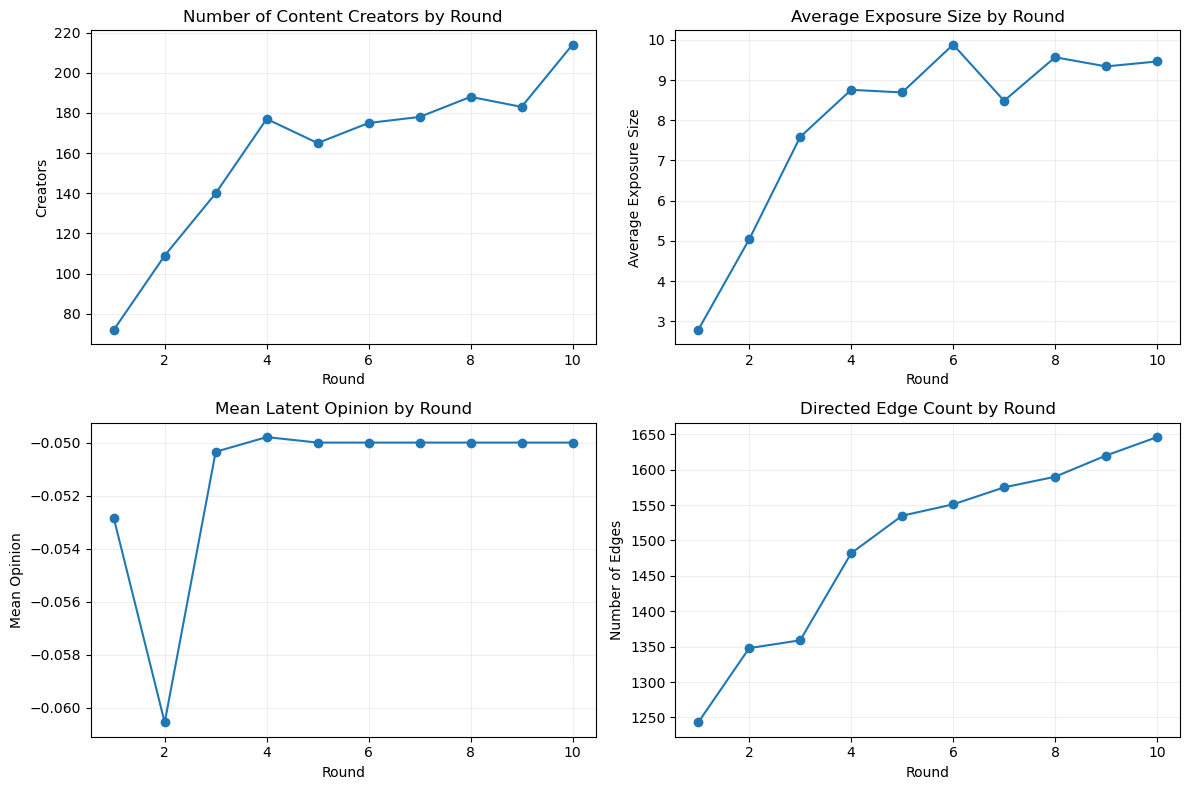

In [20]:
# ==========================================
# Cell 8: Plot time-series summaries over rounds
# ==========================================

fig, _ = plot_time_series_summaries(history_df)
plt.show()


In [21]:
# ==========================================
# Cell 9: Prepare final-round graph for visualization
# ==========================================

G_updated = prepare_graph_for_visualization(G, agents)
final_posts = all_posts_by_round[params['T_rounds']]
final_exposure_sets = all_exposure_sets_by_round[params['T_rounds']]

print('Final round prepared for visualization.')
print(f"Final number of edges: {G_updated.number_of_edges()}")


Final round prepared for visualization.
Final number of edges: 1646


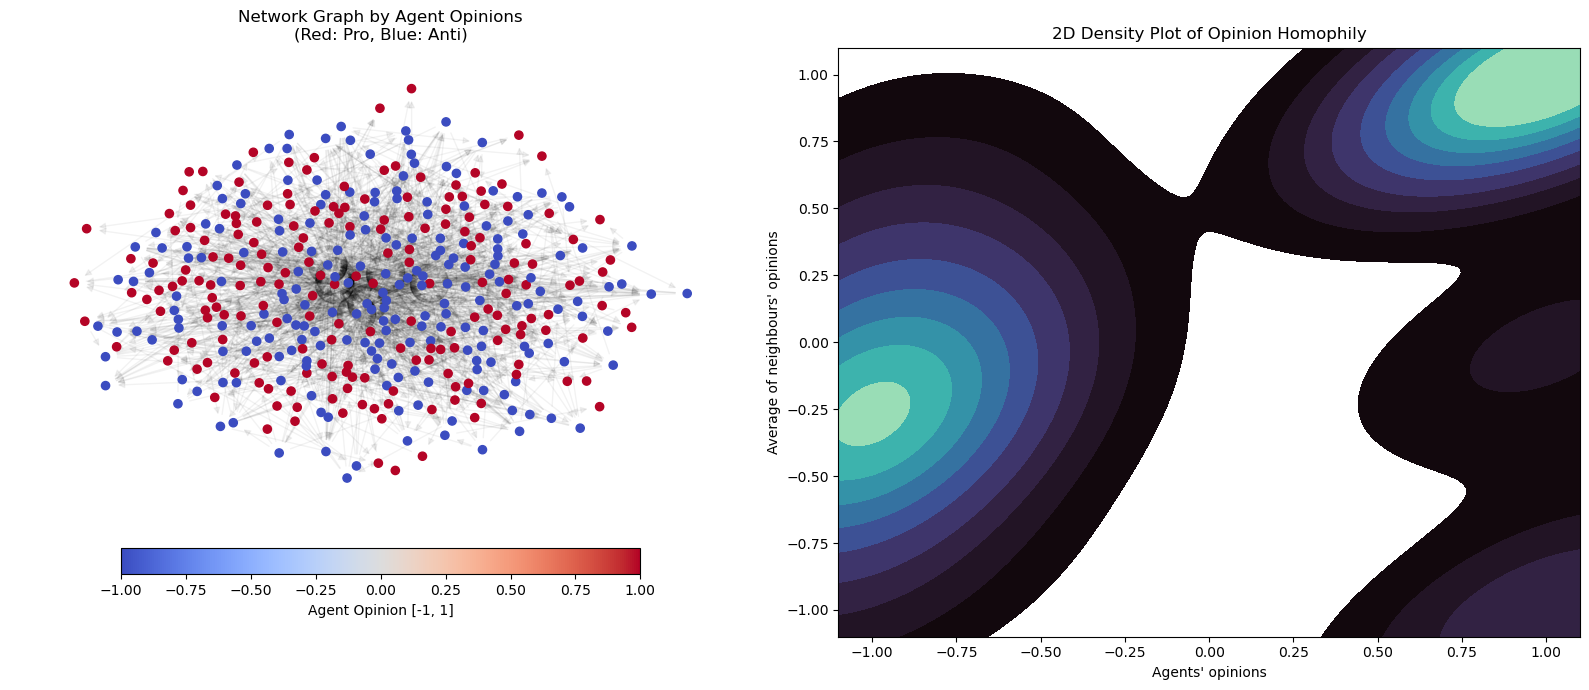

In [22]:
# ==========================================
# Cell 10: 1x2 visualization
# ==========================================

fig, _ = plot_network_and_homophily(G_updated, pos)
plt.show()


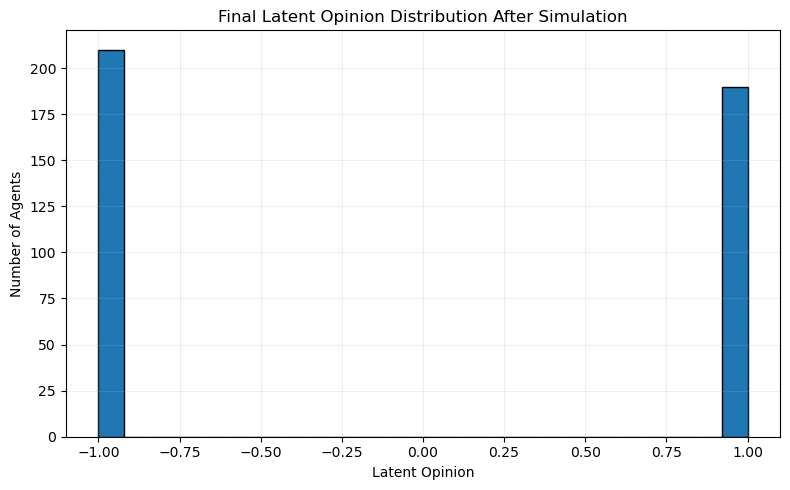

In [23]:
# ==========================================
# Cell 11: Final opinion distribution
# ==========================================

fig, _ = plot_final_opinion_distribution(agents)
plt.show()


In [ ]:
# ==========================================
# Cell 12: Highlight opinion leaders
# ==========================================

fig, _ = plot_opinion_leaders(G_updated, agents, pos)
plt.show()
